In [16]:
# Setup

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import os

# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

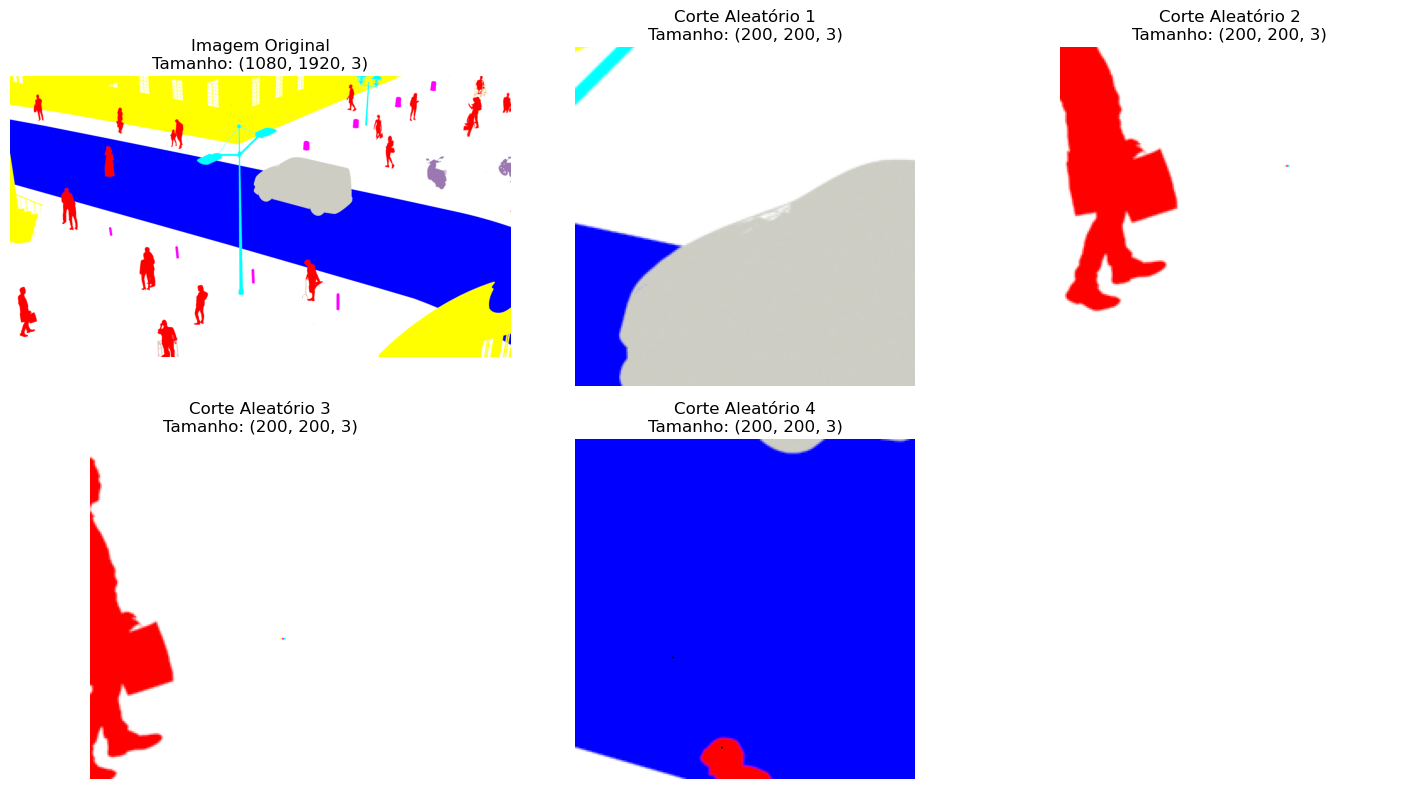

Dimensões da imagem original: (1080, 1920, 3)
Dimensões após o corte aleatório: (200, 200, 3)


In [17]:
# Testes das classes de Aumento de Dados do Keras 3

# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_crop/
# keras.layers.RandomCrop(height, width, seed=None, data_format=None, name=None, **kwargs)

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)

# Expandir dimensões para simular um batch
image_batch = tf.expand_dims(image_tensor, 0)

# Criar a camada RandomCrop
random_crop_layer = tf.keras.layers.RandomCrop(height=200, width=200, seed=42)

# Gerar múltiplos cortes aleatórios
num_crops = 4
crops = []
for i in range(num_crops):
    # Definir 'training=True' para forçar cortes aleatórios
    cropped = random_crop_layer(image_batch, training=True)
    crops.append(cropped[0])  # Removendo a dimensão do batch

# Visualizar a imagem original e os cortes
plt.figure(figsize=(15, 8))

# Imagem original
plt.subplot(2, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title(f'Imagem Original\nTamanho: {image_tensor.shape}')
plt.axis('off')

# Cortes aleatórios
for i, crop in enumerate(crops):
    plt.subplot(2, 3, i + 2)
    plt.imshow(crop.numpy().astype('uint8'))
    plt.title(f'Corte Aleatório {i+1}\nTamanho: {crop.shape}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar as dimensões
print("Dimensões da imagem original:", image_tensor.shape)
print("Dimensões após o corte aleatório:", crops[0].shape)

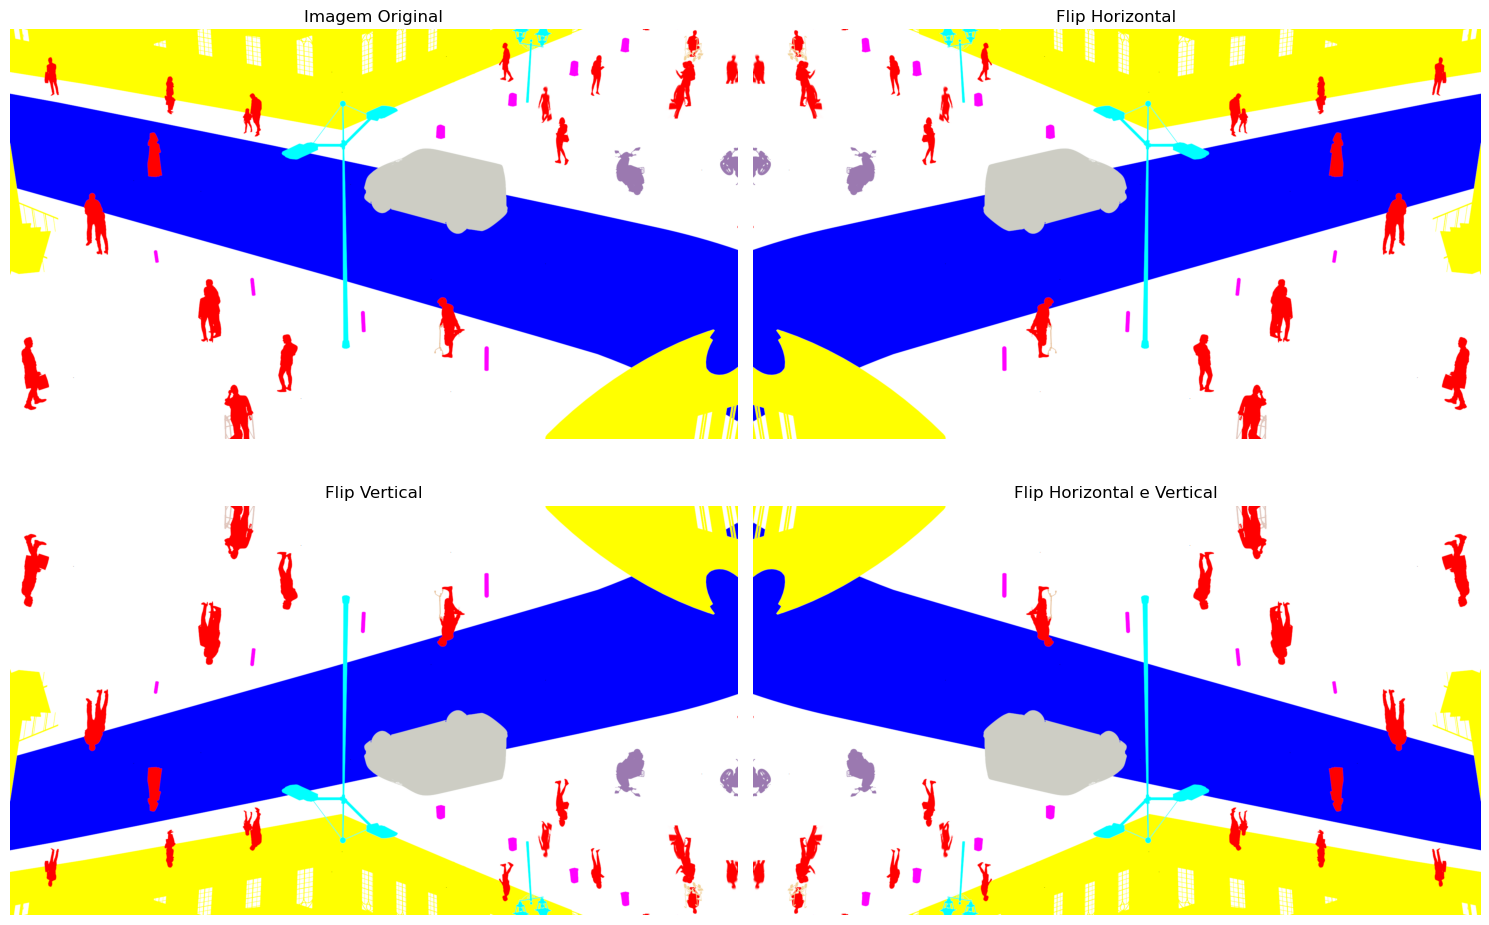

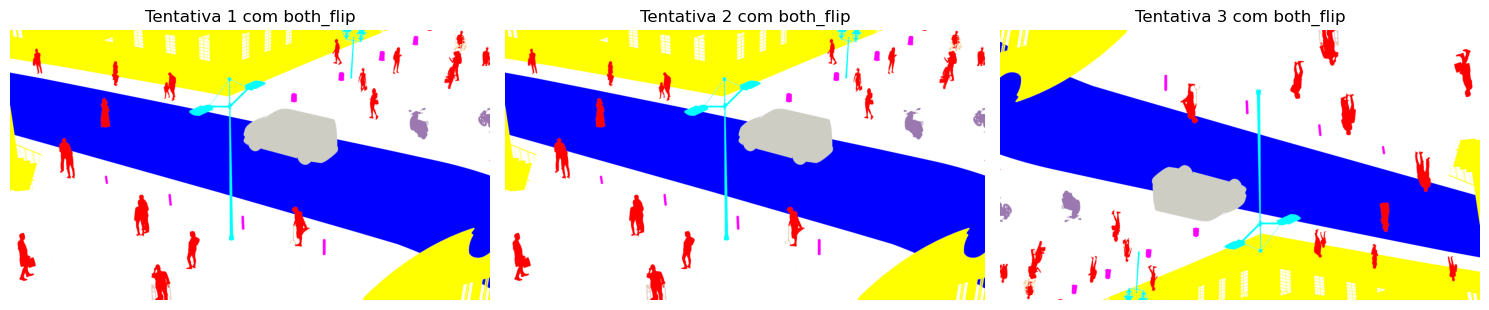

In [20]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_flip/
# keras.layers.RandomFlip(mode="horizontal_and_vertical", seed=None, data_format=None, **kwargs)

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)

# Expandir dimensões para simular um batch
image_batch = tf.expand_dims(image_tensor, 0)

# Criar as camadas RandomFlip com diferentes modos
horizontal_flip = tf.keras.layers.RandomFlip("horizontal", seed=42)
vertical_flip = tf.keras.layers.RandomFlip("vertical", seed=42)
both_flip = tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=42) # Padrão

# Aplicar os diferentes tipos de flip, 'training=True' para forçar o flip
flipped_h = horizontal_flip(image_batch, training=True)
flipped_v = vertical_flip(image_batch, training=True)
flipped_hv = both_flip(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Flip horizontal
plt.subplot(2, 2, 2)
plt.imshow(flipped_h[0].numpy().astype('uint8'))
plt.title('Flip Horizontal')
plt.axis('off')

# Flip vertical
plt.subplot(2, 2, 3)
plt.imshow(flipped_v[0].numpy().astype('uint8'))
plt.title('Flip Vertical')
plt.axis('off')

# Flip horizontal e vertical
plt.subplot(2, 2, 4)
plt.imshow(flipped_hv[0].numpy().astype('uint8'))
plt.title('Flip Horizontal e Vertical')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar comportamento aleatório
plt.figure(figsize=(15, 5))
for i in range(3):
    # A cada iteração, pode haver ou não o flip
    flipped = both_flip(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(flipped[0].numpy().astype('uint8'))
    plt.title(f'Tentativa {i+1} com both_flip')
    plt.axis('off')

plt.tight_layout()
plt.show()